#INTRODUCTION

Chemical and electrical signals are passed from neuron to neuron through synapses. Through these signals, a neuron can affect the activity of another neuron, but a given neuron only 'knows itself', in the sense that it can only change itself. Realizing this, Donald Hebb postulated that a neuron can only know the input it receives and its own activity, and any type of change in connection between two neurons, can only depend on these variables. Thus Hebb's postulate states that "*when a neuron excites or takes part repeatedly in firing another neuron, there is potentiation of the postsynaptic neuron*". In other words, when a neuron increases the firing of another neuron, there is potentiation of the synapse. Conversely, synapses are depressed if neurons are not "informing" the post synaptic neuron.

In this project, we will see how self-organisation of topography emerges from network plasticity via Hebbian rules. Our network will learn from correlations between co-activated cells ("association"), across stimulus presentations. In this case we will use a toy problem which imagines pairs of lines as sensory stimuli, and where the network discovers which neurons are most likely to be activated together.

With Hebb's rule as a basis, the network will learn without an explicit error signal from the environment, that is, **without supervision**. As we train our network on these input patterns self-organization will happen in **weight space**, after which the network learns the statistical regularities in the input.

For this project we will zoom out from biological complexity to focus on operating principles. For instance, we will assume that a [real number](https://en.wikipedia.org/wiki/Real_number) represents the synaptic strength between a pre and a postsynaptic neuron. We will also regard the activity of neurons themselves as real numbers (bounded between 0 and 1, possibly representing firing rate of a given neuronal population, between minimum and maximum firing rates). Another simplification is that we will be dealing with 'discrete dynamics', that is, our network will be updated in "discrete" time steps. You may spot other simplifications as we go along. As stark as they may be, none is too tragic, and the main plasticity phenomena due to Hebbian rule is known to be robust when the biological complexity is re-introduced into the picture.

What does the network learn and how can we observe the process? Read on!

**Pre-requisites**
- How to compute the propagation of activity in a neural network

# Learning Goals

- Distinguish supervised learning from unsupervised learning.
- Explain Hebbian plasticity and why its basic form is unstable.
- Identify statistical regularities in stimulus ensembles.
- Compute activity-dependent synaptic weight updates.
- Explain how Hebbian learning extracts regularities from inputs.
- Construct stimulus patterns for unsupervised training.
- Train an unsupervised network by repeatedly presenting stimuli.
- Compare and interpret network weights before and after learning.
- Normalize weights using stable learning rules such as Oja's rule and BCM theory.
- Relate Hebbian learning in spiking networks to spike-timing-dependent plasticity (STDP).

# INITIALISATION

In [1]:
# Intrinsic plasticity: Foldiak rate model
import numpy as np
import matplotlib.pyplot as plt

# SIMPLE HEBBIAN PLASTICITY

In this project we will be using a simple feedforward network with multiple input neurons and a single **linear** output neuron.

$$y = \sum w_i x_i$$

A change in the value of synaptic weight $w_{i}$ represents synaptic plasticity. If the change in weight ($\Delta w_i$) is positive we call it potentiation and negative we call depression.

In the simplest version of Hebbian learning the change of weight is directly proportional to the activity of the pre-synaptic ($x_i$) and the post-synaptic ($y$) neuron. In the formula below you should be able to see that $\Delta w_{i}$ grows when pre- and post-synaptic neurons are co-activated (e.g. both have a  positive value).

------

$$
\Delta w_{i}(t+1) = x_i(t) y(t)
$$

Such that the new weights (at $t+1$) would be

$$
w_{ij}(t+1) = w_{i}(t) + \Delta w_{i}(t+1)
$$

------

where $\Delta w_{ij}$ is the change in synaptic weight $w_{ij}$ as a function of the presynaptic neuron $j$, the presynaptic neuron's activity $x_i$ (i.e. the firing rate) and the postsynaptic neuron's activity $y_j$.

In [2]:
# Interplay of Hebbian and homeostatic plasticity in neuronal networks

# Set model parameters
n_trials = 1000

alpha_w = 10**(-4)            # learning rate for weights
ytarget = 10                  # output target
tau_theta = 50                # time constant for theta
dt = 1                        # time step (ms)

## Input Patterns

Before we train our network, we have to decide on the inputs it will receive: the *patterns* aka *statistical regularities*, present in the environment.

Let us assume that the inputs to our network will consist of pairs of vertical and horizontal lines, in a N x N pixel matrix. Take N to be 5.

Stretching this abstract problem onto a problem for the somatosensory system, you could think about the input patterns, the lines, as the receptive fields activated from tactlie stimulation on receptors in a hand (e.g., each finger has 5 receptors organized vertically).

Vertical lines are thus 'whole fingers (top to bottom)' and 'horizontal lines' represent stimuli across the hand. For instance, we can imagine the activation pattern as holding pencils on the hand.

Though this is an artificial rendition of the problem, it is easy to extend this to more plausible schemes.

We start with creating a combinatoric set of line **input patterns**, defined below. We make a set of all possible pairs of vertical and horizontal lines across the grid.

The idea behind using pairs of lines, is that the more robust statistical regularity is the one representing the pixels belonging to a single line. That is, the pixels from one line appear more often together than the pixels from two lines.

In [3]:
# Generate input patterns


# N is number of pixels in the pattern
# p_bar is the probability of a bar in a given orientation

def getPattern(N,p_bar):
    pattern = np.zeros([N,N])

    #vertical bars
    onbar = np.random.rand(N) < p_bar
    pattern[:,onbar]=1

    #horizontal bars
    onbar = np.random.rand(N) < p_bar
    pattern[onbar,:]=1

    return pattern

def getBiasedPattern(N,p_bar):
    pattern = np.zeros([N,N])

    #vertical bars
    onbar = np.random.rand(N) < p_bar
    pattern[:,onbar]=1

    #add a systematic bias
    if np.random.rand() < 0.1:
        pattern[:,3] = 1

    #horizontal bars
    onbar = np.random.rand(N) < p_bar;
    pattern[onbar,:]=1

    return pattern

---
**Exercise:** Try to predict the output of the code above, then run the code below. If it matches, great! If it doesn't try to undersand what the code does, line by line!

---

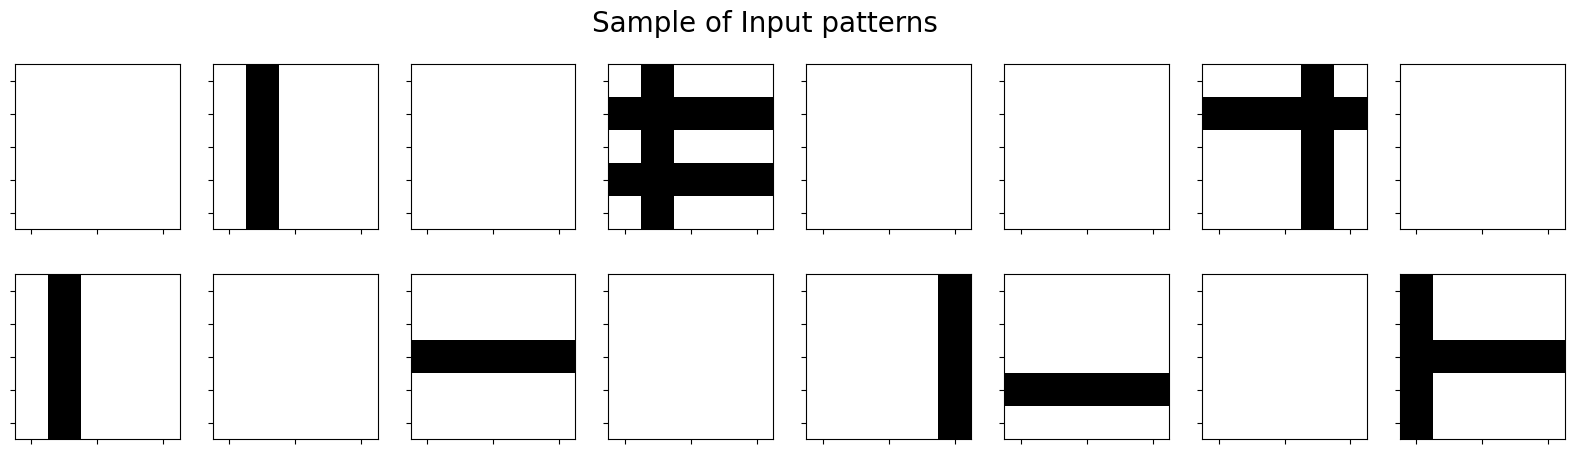

In [4]:
# Let's produce some input patterns
N = 5                         # number of rows & columns in inputs
p_bar = 0.2                   # probability of vertical & horizontal bars in input

# Show Examples of input patterns
fig, axs = plt.subplots(2,8,figsize=(20,5))
fig.suptitle('Sample of Input patterns', fontsize=20)
for i in range(2):
    for j in range(8):
        axs[i,j].imshow(getPattern(N,0.1),cmap='binary')
        # axs[i,j].imshow(getBiasedPattern(N,0.1),cmap='binary')
        axs[i,j].set_yticklabels([])
        axs[i,j].set_xticklabels([])
plt.show()

Note that in the set of stimuli above, receptive fields belonging to a single row or column are more often stimulated than line combinations. What we mean by this is that it is statistically more likely to see neurons with receptive fields belonging to the same line activated together than a particular combination of lines (for instance, the neurons in the first row are stimulated 9 times together, but the pattern with a 'cross in the middle' is present only once in the stimulus set). This has a consequence for the trained weights of our network, as we hope you will see towards the end of this project.

## Algorithm

Training is done by feeding our input patterns one by one to a "cortical" network, calculating the activities and from there calculating incremental weight changes. In analogy of a 'blank slate' cortex, our network will start with  randomized connection weights.

The algorithm step by step looks like this:
```python
# Select a learning rate
eta = 0.1

# Initialize Weight Matrix with random mumbers
W = rand(N * N)

For each input pattern X:
  For each w_i in W and x_i in X:

  y = sum(w_i * x_i)
  Delta_w = x_i * y - y^2 * w_i
  new_w_i = eta * Delta_w + old_w_i
  return new_w_i
```

## Weight matrix

As you have learned, *adjacency matrices* are matrices that represent connections between nodes in a network. In this case their elements will be **real numbers**, each entry representing the strength of a given connection. We can call this special type of an adjacency matrix a **weight matrix**. And furthermore, as we have a one layer feed forward neural network, the weight matrix is in fact a **weight vector** of shape = (N*N,1).

In [5]:
N = 5
n_trials = 1000

# Initialize weight vectors (a stack of vectors, each column being a trial)
w = np.zeros([N*N,n_trials])

# randomize the initial weights
w[:,0] = np.random.rand(N*N)

## Oja's Rule

The standard version of Hebbian learning has the problem that weigths continue to grow indefinitely if neurons are always active. To counter that effect, Oja suggested a normalization factor to contain this growth:

This is Oja's rule

$$\Delta wi = \eta (x_i y - y^2 w_i)$$

By calculating the correlation of input and output and normalizing it by the total wieghts, Oja's rule extracts the 1st principle component of the covariance matrix of the input data.

In [6]:
# this function returns Oja's weight updates
def update_weights_Oja(x,y,w):
    return x*y-w*y**2



## Train Network


In [7]:
# Set model parameters

eta = 10**(-3)            # learning rate for weights

y = np.zeros([n_trials])         # initialize output vector
# theta = 5*np.ones([n_trials])    # sliding threshold theta

# Train network
for t in range(n_trials-1):

    #Generate pattern
    pattern = getPattern(N,p_bar)
    # pattern = getBiasedPattern(N,p_bar)

    #Linearize pattern
    inputs = np.reshape(pattern,N*N)

    #Normalize overall "brightness" of each pattern
    scaling_factor = 2*N - 1 #avoid very small values for input
    if sum(inputs) != 0: #don't normalize if input is blank
        inputs = scaling_factor * inputs / sum(inputs)

    #Calculate output
    y[t] = np.dot(w[:,t],inputs)                                             # compute the output
    w[:,t+1] = w[:,t] + eta *  update_weights_Oja(inputs,y[t],w[:,t])       # update of the weights

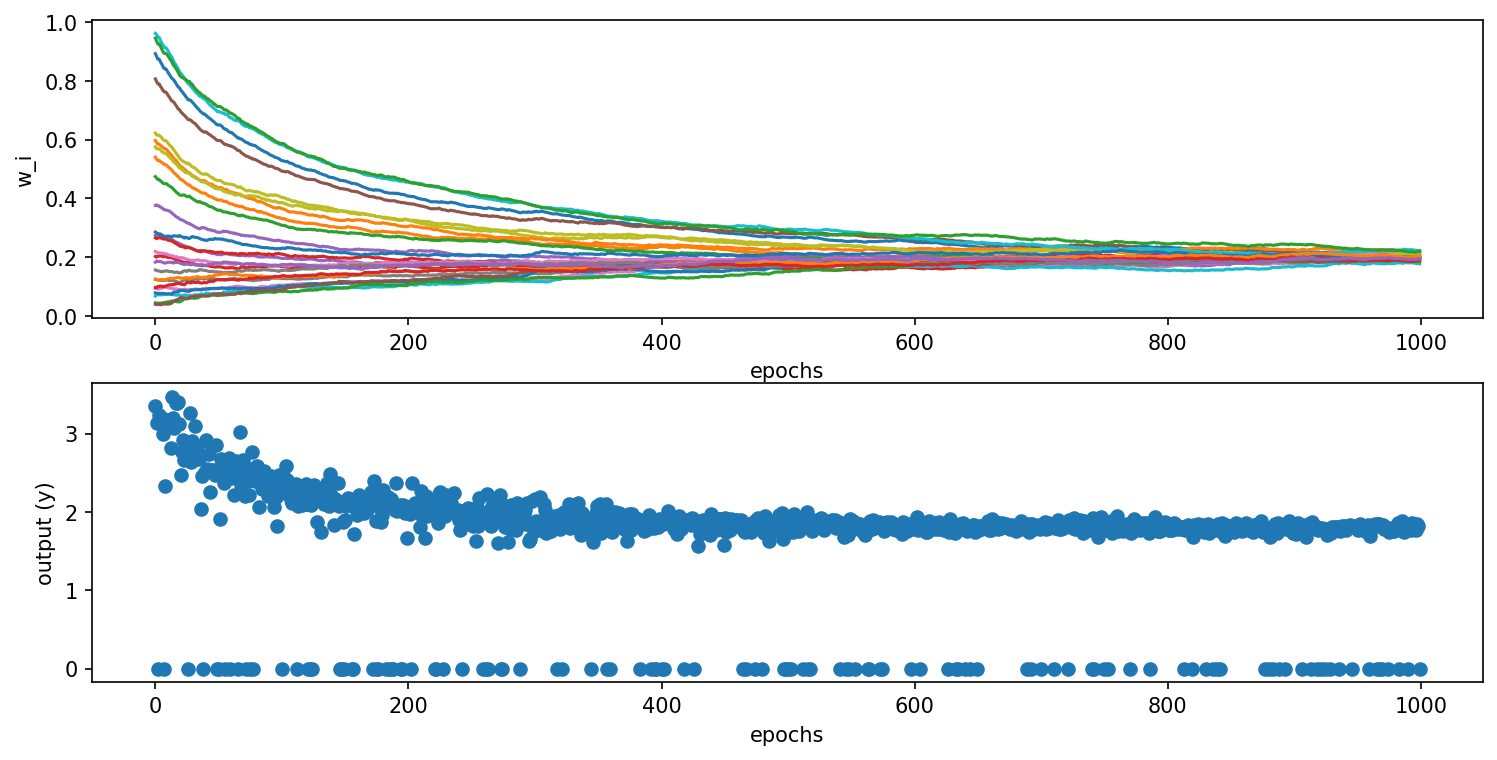

In [8]:
fig, axs = plt.subplots(2,figsize=(10,5),dpi=150)
fig.tight_layout()
[axs[0].plot(w[i,:]) for i in range(N*N) ]
axs[0].set(ylabel='w_i')
axs[0].set(xlabel='epochs')

axs[1].scatter(np.arange(len(y)),y)
axs[1].set(ylabel='output (y)',xlabel='training samples')
axs[1].set(xlabel='epochs')
plt.show()

---
**Exercise**: Describe what you see in the plots above. Now consider the first plot. What would you expect for the weights if we were not using Oja's rule?

---

## Plot Weight Matrix

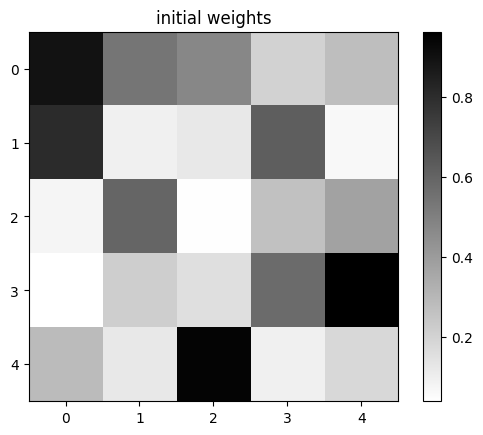

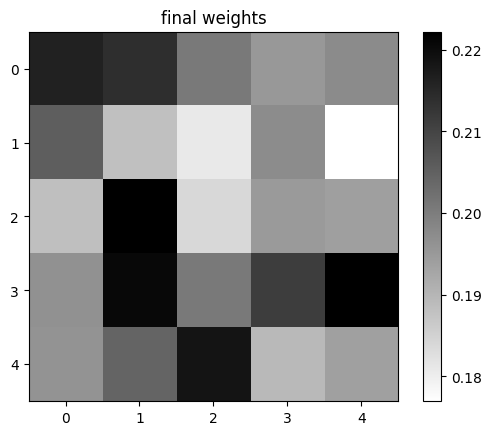

In [9]:
# Plot initial weights
weights = np.reshape(w[:,0],(N,N))
plt.imshow(weights,cmap='binary')
plt.colorbar()
plt.title('initial weights')
plt.show()

# Plot final weights
weights = np.reshape(w[:,-1],(N,N))
#p = reshape(pattern,size,size)
plt.imshow(weights,cmap='binary')
plt.colorbar()
plt.title('final weights')
plt.show()

## Questions:
- Explain what you see in the output matrix.
- Re-run the code from the beginning. Is the weight matrix always the same?
- We are using `GetBiasedPatterns()`. What is special about it? And what happens if we change that to `GetPatterns()` and rerun the code multiple times?


# CONCLUSION

The simple version of Hebb here underlies our understanding of much of the organization of topographical maps such as somatotopical maps, retinotopical maps, motor maps and many others. It can also work with semantic association (bananas are yellow), and thus it becomes an abstract mechanism of clustering like with like.

The addition of normalization also allows Hebb like rules to better separate patterns and to create contrast. The organization of the dorsal stream in the visual system can be obtained via Hebb like rules across the different layers.

Other rules based on Hebb plus the idea that there must be some mechanism to balance weight change as a function of activity (the BCM rule, for example) have been leveraged to explain the formation of occular preference columnns in the visual cortex, or STDP, which is a rule that modifies weights as a function of interspike intervals, and have similar consequences on the self-organization of the network.

## Project Ideas

- Experiment with the network parameters, such as learning weights and number of neurons.
- Extend number of output neurons. Do different neurons acquire different 'receptive fields'?
- Experiment with different processes creating pattern regularities (instead of line combinations). Can we learn to be selective about oriented bars in this way?
- Modify the code to implement 'vanilla' Hebbian learning. Describe your observations with respect to the ability of the network to learn from input regularities.

# Credits

Code adapted from:
https://github.com/argalloni/Unsupervised_learning/blob/master/Patterns_Oja_PCA.ipynb